In [1]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import shutil
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
from d2l import torch as d2l

In [3]:
def load_data_fashion_mnist(batch_size, resize=None, num_workers=4):
    # 工作目录下的数据根（torchvision 会在 /kaggle/working 下创建 FashionMNIST 文件夹）
    work_root = "/kaggle/working"
    work_data_dir = os.path.join(work_root, "FashionMNIST")
    
    # 永久数据集目录（如果用户已上传）
    persistent_data_dir = "/kaggle/input/FashionMNIST"
    
    # 辅助函数：检查数据是否已存在且有效（包含 raw 或 processed 子目录）
    def is_data_valid(path):
        return os.path.exists(path) and (
            os.path.exists(os.path.join(path, "raw")) or
            os.path.exists(os.path.join(path, "processed"))
        )
    
    # 如果工作目录下已有有效数据，直接使用
    if is_data_valid(work_data_dir):
        print("数据已存在于工作目录，直接加载。")
    else:
        # 检查永久数据集是否存在
        if is_data_valid(persistent_data_dir):
            print("从永久数据集复制到工作目录...")
            # 如果工作目录下已有目录（可能为空），先删除
            if os.path.exists(work_data_dir):
                shutil.rmtree(work_data_dir)
            # 复制永久数据集到工作目录
            shutil.copytree(persistent_data_dir, work_data_dir)
            print("复制完成。")
        else:
            print("未找到永久数据集，将从网络下载到工作目录。")
            print("下载中...")
            # 临时下载到工作目录，torchvision 会在 work_root 下创建 FashionMNIST
            trans_dummy = transforms.Compose([transforms.ToTensor()])
            # 下载训练集，仅触发下载
            _ = torchvision.datasets.FashionMNIST(
                root=work_root, train=True, transform=trans_dummy, download=True)
            print("下载完成。")
            print("="*60)
            print("请将以下文件夹上传为 Kaggle 数据集，并附加到本 Notebook：")
            print(f"  路径: {work_data_dir}")
            print("上传后，下次运行时将自动从永久数据集复制，避免重复下载。")
            print("="*60)
    
    # 数据预处理
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    # 加载数据集（此时工作目录下已有数据）
    mnist_train = torchvision.datasets.FashionMNIST(
        root=work_root, train=True, transform=trans, download=False)
    mnist_test = torchvision.datasets.FashionMNIST(
        root=work_root, train=False, transform=trans, download=False)
    
    # 创建 DataLoader
    train_loader = DataLoader(
        mnist_train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(
        mnist_test, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True)
    
    return train_loader, test_loader

# 1. Vgg-11

In [17]:
def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels  #一个块内部, 在经过第一个卷积层之后, 通道数保持不变
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

In [18]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

In [19]:
def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    # 卷积层部分
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels

    return nn.Sequential(
        *conv_blks, nn.Flatten(),
        # 全连接层部分
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10))

net = vgg(conv_arch)

In [20]:
X = torch.randn(size=(1, 1, 224, 224))
for blk in net:
    X = blk(X)
    print(blk.__class__.__name__,'output shape:\t',X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [21]:
small_conv_arch = [(1, 16), (1, 32), (2, 64), (2, 128), (2, 128)] #将前面的每个块的输出通道都除以4


loss 0.188, train acc 0.930, test acc 0.921
1056.1 examples/sec on cuda


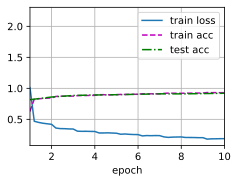

In [22]:
net = vgg(small_conv_arch)
net=nn.DataParallel(net)
device=torch.device('cuda')

lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

----
# 2. NiN

<span style="color:red;font-weight:600;font-size:16px">去掉了全连接层,很大程度上缓解了过拟合</span>

In [3]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

In [6]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

In [7]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


loss 0.400, train acc 0.849, test acc 0.853
1390.3 examples/sec on cuda


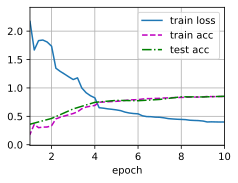

In [8]:
net=nn.DataParallel(net)
device=torch.device('cuda')
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

## 2.1.1 384直接到10跨度可能过大,尝试将384降低到128

loss 0.465, train acc 0.823, test acc 0.826
1528.6 examples/sec on cuda


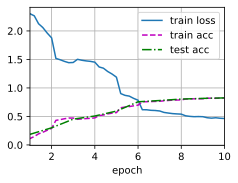

In [9]:
net_nin2 = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 128, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(128, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

net_nin2=nn.DataParallel(net_nin2)
device=torch.device('cuda')
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net_nin2, train_iter, test_iter, num_epochs, lr, device)

相比384直接到10, 128到10训练速度略快,但准确率降低.    
## 2.1.2 考虑增加一层而不是直接减少通道试试

loss 0.334, train acc 0.876, test acc 0.876
1345.0 examples/sec on cuda


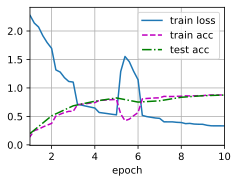

In [12]:
net_nin3 = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nin_block(384, 128, kernel_size=3, strides=1, padding=1), #add 128
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(128, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

net_nin3=nn.DataParallel(net_nin3)
device=torch.device('cuda')
lr, num_epochs, batch_size = 0.08, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net_nin3, train_iter, test_iter, num_epochs, lr, device)

增加一层后准确率增加,不过需要注意,此时需要**调整学习率**

## 2.2 如果每一个块只用一个 1*1 的卷积层呢

In [4]:
def nin_block_11(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        )

loss 0.333, train acc 0.877, test acc 0.868
1632.0 examples/sec on cuda


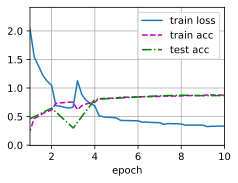

In [5]:
net_nin_11 = nn.Sequential(
    nin_block_11(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block_11(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block_11(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block_11(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

net_nin_11=nn.DataParallel(net_nin_11)
device=torch.device('cuda')
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net_nin_11, train_iter, test_iter, num_epochs, lr, device)

应该是这个数据集比较简单,所以只使用一个 1*1 卷积层甚至效果更好一点